# Step Project
## Аналіз рейтингу кави

### 1. Завантаження та зчитування даних

In [2]:

import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-07-07/coffee_ratings.csv"
file_name = "coffee_ratings.csv"

if not os.path.exists(file_name):
    r = requests.get(url)
    if r.status_code == 200:
        with open(file_name, "wb") as f:
            f.write(r.content)
data = pd.read_csv(file_name)
data.head()


,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


### 2. Великі експортери кави (top-10)

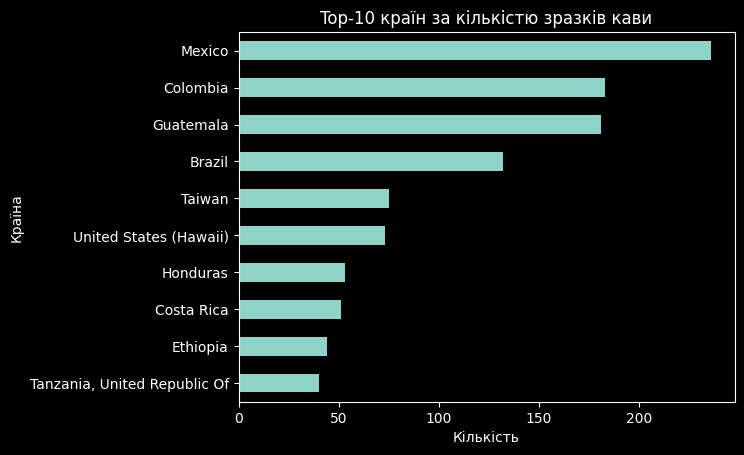

In [3]:

top_countries = data['country_of_origin'].value_counts().head(10)

plt.figure()
top_countries.sort_values().plot(kind='barh')
plt.title("Top-10 країн за кількістю зразків кави")
plt.xlabel("Кількість")
plt.ylabel("Країна")
plt.show()


### 3. Кореляції між показниками оцінки

In [5]:
data.columns.tolist()

['total_cup_points',
 'species',
 'owner',
 'country_of_origin',
 'farm_name',
 'lot_number',
 'mill',
 'ico_number',
 'company',
 'altitude',
 'region',
 'producer',
 'number_of_bags',
 'bag_weight',
 'in_country_partner',
 'harvest_year',
 'grading_date',
 'owner_1',
 'variety',
 'processing_method',
 'aroma',
 'flavor',
 'aftertaste',
 'acidity',
 'body',
 'balance',
 'uniformity',
 'clean_cup',
 'sweetness',
 'cupper_points',
 'moisture',
 'category_one_defects',
 'quakers',
 'color',
 'category_two_defects',
 'expiration',
 'certification_body',
 'certification_address',
 'certification_contact',
 'unit_of_measurement',
 'altitude_low_meters',
 'altitude_high_meters',
 'altitude_mean_meters']

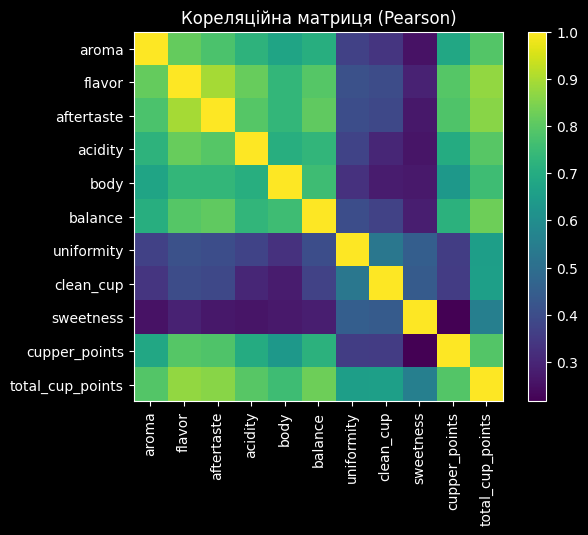

In [6]:

score_cols = [
    'aroma',
    'flavor',
    'aftertaste',
    'acidity',
    'body',
    'balance',
    'uniformity',
    'clean_cup',
    'sweetness',
    'cupper_points',
    'total_cup_points'
]

corr = data[score_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(score_cols)), score_cols, rotation=90)
plt.yticks(range(len(score_cols)), score_cols)
plt.title("Кореляційна матриця (Pearson)")
plt.show()


### 4. Вплив кольору зерен на загальну оцінку

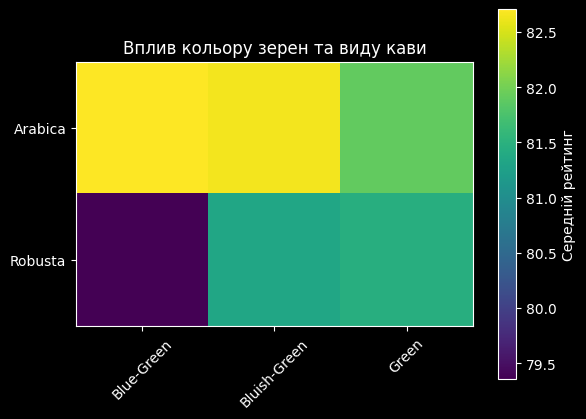

In [7]:

pivot = data.pivot_table(
    index='species',
    columns='color',
    values='total_cup_points',
    aggfunc='mean'
)

plt.figure()
plt.imshow(pivot)
plt.colorbar(label="Середній рейтинг")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Вплив кольору зерен та виду кави")
plt.show()


### 5. Вплив країни походження на якість кави

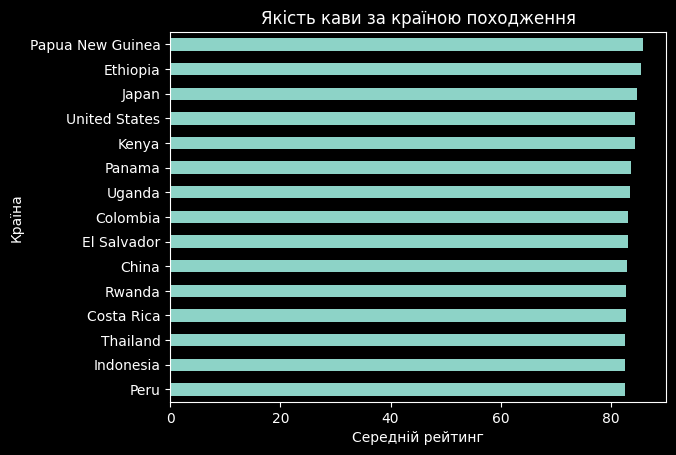

In [13]:

country_quality = (
    data.groupby('country_of_origin')['total_cup_points']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure()
country_quality.sort_values().plot(kind='barh')
plt.xlabel("Середній рейтинг")
plt.ylabel("Країна")
plt.title("Якість кави за країною походження")
plt.show()


### 6. Вплив висоти над рівнем моря

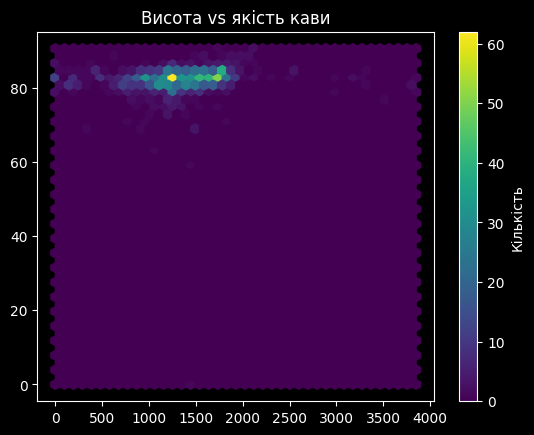

In [11]:
clean = data[['altitude_mean_meters', 'total_cup_points']].dropna()

clean = clean[
    (clean['altitude_mean_meters'] > 0) &
    (clean['altitude_mean_meters'] < 4000)
]
plt.figure()

plt.hexbin(
    clean['altitude_mean_meters'],
    clean['total_cup_points'],
    gridsize=40
)

plt.colorbar(label="Кількість")
plt.title("Висота vs якість кави")
plt.show()

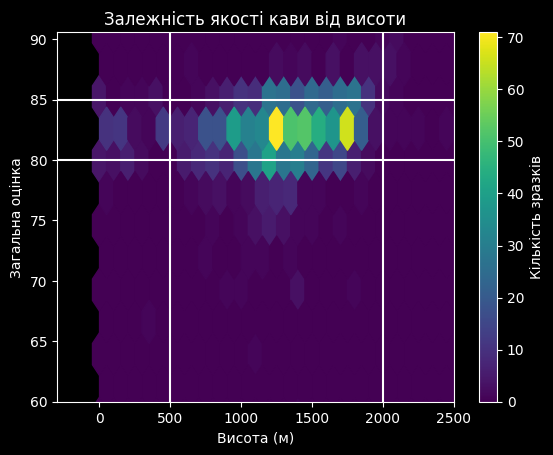

In [9]:

clean = data[['altitude_mean_meters','total_cup_points']].dropna()
clean = clean[(clean['altitude_mean_meters'] >= 0) & (clean['altitude_mean_meters'] <= 3000)]

plt.figure()
plt.hexbin(
    clean['altitude_mean_meters'],
    clean['total_cup_points'],
    gridsize=30
)
plt.colorbar(label="Кількість зразків")
plt.axhline(80)
plt.axhline(85)
plt.axvline(500)
plt.axvline(2000)
plt.xlim(-300, 2500)
plt.ylim(60, clean['total_cup_points'].max())
plt.xlabel("Висота (м)")
plt.ylabel("Загальна оцінка")
plt.title("Залежність якості кави від висоти")
plt.show()
